Домашняя работа №8

In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np 
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import random_split, DataLoader
import torch.optim as optim
import csv
import json

In [2]:
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

In [ ]:
def plot_history(history, title):
    epochs = np.arange(1, len(history["train_loss"] ) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label = "train_loss")
    plt.plot(epochs, history["val_loss"], label = "val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True)
    plt.title(title + " (loss)")
    plt.legend()
    plt.savefig(f"artifacts/figures/{title} (loss)")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " (accuracy)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"artifacts/figures/{title} (accuracy)")
    plt.show()
     


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [6]:
train_full = torchvision.datasets.EMNIST(split="balanced", root = "./data", train = True, download = True, transform = transform)

test_df = torchvision.datasets.EMNIST(split = "balanced", root = "./data", train = False, download = True, transform = transform)

In [7]:
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

In [8]:
gen = torch.Generator().manual_seed(42)
train_df, val_df = random_split(train_full, [train_size, val_size], generator = gen)

In [9]:
BATCH_SIZE = 128
NUM_WORKERS = 0

In [10]:
train_loader = DataLoader(train_df, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

val_loader = DataLoader(val_df, batch_size=BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS, pin_memory = (device.type == "cuda"))

test_loader = DataLoader(test_df, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS, pin_memory = (device.type == "cuda"))

In [11]:
class_names = train_full.classes
print("classes:", class_names)
print("len_classes:", len(class_names))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
len_classes: 47


In [12]:
# Проверка размеров и типов батча
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

# Проверка диапазонов значений
print(f"Min: {x_batch.min().item():.4f}")
print(f"Max: {x_batch.max().item():.4f}")
print(f"Mean: {x_batch.mean().item():.4f}")
print(f"Std: {x_batch.std().item():.4f}")

x_batch: torch.Size([128, 1, 28, 28]) torch.float32
y_batch: torch.Size([128]) torch.int64
Min: -1.0000
Max: 1.0000
Mean: -0.6348
Std: 0.6805


In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (64, 32),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    

In [14]:
model = MLP(input_dim=28*28, hidden_dims=(256, 128), num_classes=47)
dummy_input = torch.randn(8, 1, 28, 28)  # batch=8, 1 канал, 28x28
logits = model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {logits.shape}")  # Ожидается: [8, 47]
print(f"Logits range: [{logits.min():.3f}, {logits.max():.3f}]")
print(f"Is logits (no softmax): {logits.min().item() < 0}")  # Должно быть True

Input shape:  torch.Size([8, 1, 28, 28])
Output shape: torch.Size([8, 47])
Logits range: [-0.299, 0.395]
Is logits (no softmax): True


In [15]:
def accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim = 1)
    return (preds == y_true).float().mean().item()

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none = True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_acc / n_batches

In [17]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()    
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [18]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [19]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1): 
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)


        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )
        
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break 
            
    return history

Эксперементы

##### E1 :  MLP сложнее (2 скрытых слоя и/или больше нейронов), без Dropout и BatchNorm.

epoch 01/20 | train loss=1.7646, acc=0.5172 | val loss=1.2260, acc=0.6500
epoch 02/20 | train loss=1.1160, acc=0.6751 | val loss=1.0295, acc=0.6933
epoch 03/20 | train loss=0.9602, acc=0.7141 | val loss=0.9315, acc=0.7229
epoch 04/20 | train loss=0.8718, acc=0.7378 | val loss=0.8523, acc=0.7453
epoch 05/20 | train loss=0.8138, acc=0.7526 | val loss=0.8312, acc=0.7469
epoch 06/20 | train loss=0.7704, acc=0.7626 | val loss=0.8093, acc=0.7538
epoch 07/20 | train loss=0.7378, acc=0.7698 | val loss=0.7813, acc=0.7642
epoch 08/20 | train loss=0.7120, acc=0.7767 | val loss=0.7548, acc=0.7718
epoch 09/20 | train loss=0.6924, acc=0.7830 | val loss=0.7520, acc=0.7703
epoch 10/20 | train loss=0.6769, acc=0.7852 | val loss=0.7342, acc=0.7743
epoch 11/20 | train loss=0.6581, acc=0.7909 | val loss=0.6964, acc=0.7887
epoch 12/20 | train loss=0.6484, acc=0.7928 | val loss=0.7056, acc=0.7850
epoch 13/20 | train loss=0.6397, acc=0.7950 | val loss=0.6938, acc=0.7893
epoch 14/20 | train loss=0.6280, acc=0

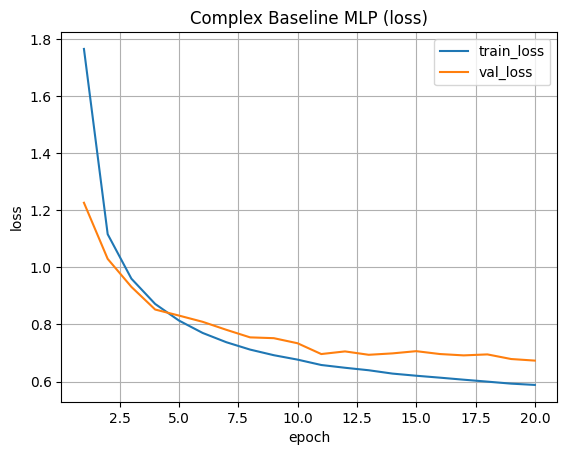

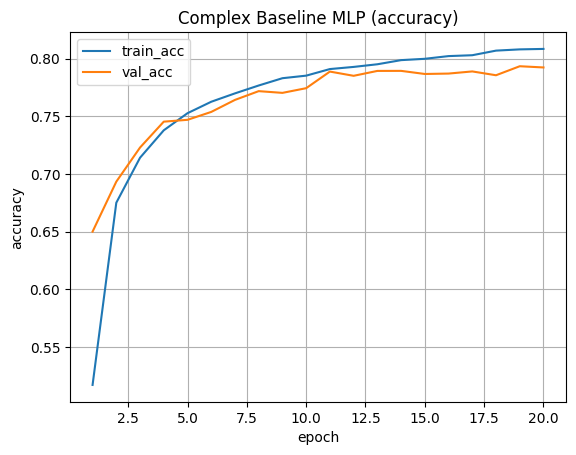

In [20]:
baseline_complex = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_complex.parameters(), lr=1e-3)

history_complex = fit(
    baseline_complex, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
)

plot_history(history_complex, title="Complex Baseline MLP")

##### E2 : как E1, но добавить Dropout (например, 0.2-0.5).

epoch 01/20 | train loss=2.5711, acc=0.2780 | val loss=1.5600, acc=0.5891
epoch 02/20 | train loss=2.0080, acc=0.4104 | val loss=1.3651, acc=0.6197
epoch 03/20 | train loss=1.8840, acc=0.4457 | val loss=1.2910, acc=0.6408
epoch 04/20 | train loss=1.8257, acc=0.4608 | val loss=1.2384, acc=0.6537
epoch 05/20 | train loss=1.7690, acc=0.4756 | val loss=1.1904, acc=0.6556
epoch 06/20 | train loss=1.7443, acc=0.4826 | val loss=1.1536, acc=0.6655
epoch 07/20 | train loss=1.7162, acc=0.4905 | val loss=1.1403, acc=0.6743
epoch 08/20 | train loss=1.6960, acc=0.4970 | val loss=1.1247, acc=0.6700
epoch 09/20 | train loss=1.6840, acc=0.4977 | val loss=1.1346, acc=0.6731
epoch 10/20 | train loss=1.6659, acc=0.5028 | val loss=1.0863, acc=0.6817
epoch 11/20 | train loss=1.6528, acc=0.5071 | val loss=1.0857, acc=0.6806
epoch 12/20 | train loss=1.6416, acc=0.5098 | val loss=1.0730, acc=0.6822
epoch 13/20 | train loss=1.6324, acc=0.5109 | val loss=1.0667, acc=0.6818
epoch 14/20 | train loss=1.6236, acc=0

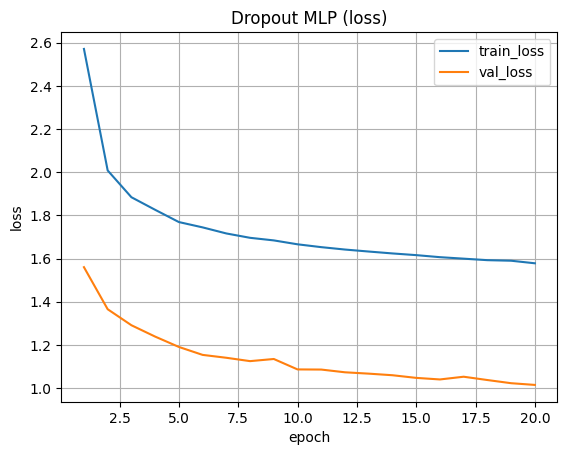

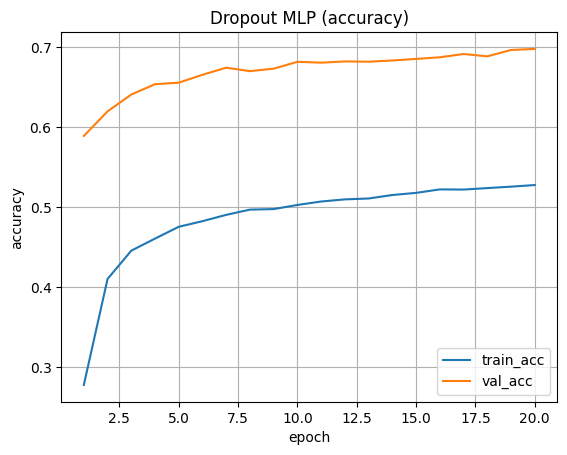

In [21]:
model_drop = MLP(hidden_dims=(64, 32), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_drop.parameters(), lr=1e-3)

history_drop = fit(
    model_drop, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
)

plot_history(history_drop, title="Dropout MLP")

##### E3 : как E1, но добавить BatchNorm (в типичном месте между Linear и активацией).

epoch 01/20 | train loss=1.6222, acc=0.6122 | val loss=0.9129, acc=0.7370
epoch 02/20 | train loss=0.7906, acc=0.7598 | val loss=0.7259, acc=0.7744
epoch 03/20 | train loss=0.6697, acc=0.7883 | val loss=0.6588, acc=0.7905
epoch 04/20 | train loss=0.6192, acc=0.8001 | val loss=0.6346, acc=0.7984
epoch 05/20 | train loss=0.5821, acc=0.8089 | val loss=0.6134, acc=0.8010
epoch 06/20 | train loss=0.5589, acc=0.8159 | val loss=0.5947, acc=0.8095
epoch 07/20 | train loss=0.5397, acc=0.8203 | val loss=0.5965, acc=0.8090
epoch 08/20 | train loss=0.5240, acc=0.8257 | val loss=0.5792, acc=0.8122
epoch 09/20 | train loss=0.5105, acc=0.8294 | val loss=0.5736, acc=0.8138
epoch 10/20 | train loss=0.5019, acc=0.8304 | val loss=0.5677, acc=0.8144
epoch 11/20 | train loss=0.4934, acc=0.8334 | val loss=0.5662, acc=0.8165
epoch 12/20 | train loss=0.4839, acc=0.8360 | val loss=0.5596, acc=0.8194
epoch 13/20 | train loss=0.4775, acc=0.8381 | val loss=0.5559, acc=0.8182
epoch 14/20 | train loss=0.4683, acc=0

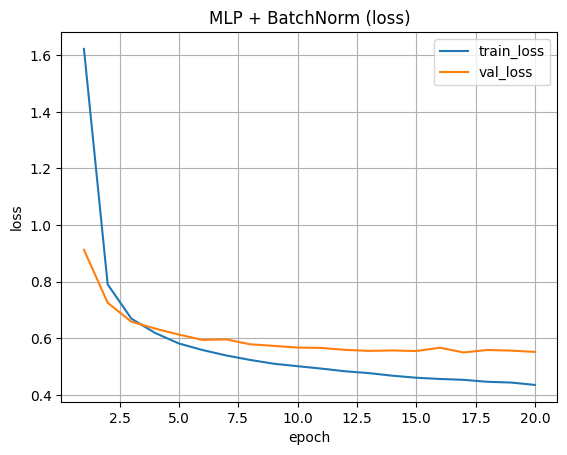

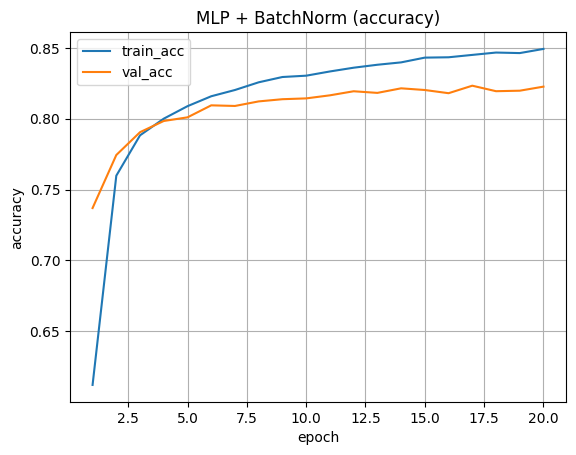

In [22]:
model_bn = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bn.parameters(), lr=1e-3)

history_bn = fit(
    model_bn, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
)

plot_history(history_bn, title="MLP + BatchNorm")

##### E4 : выбрать лучший из E2/E3 по val_accuracy и обучить его с EarlyStopping (patience 3-5).

epoch 01/50 | train loss=2.3445, acc=0.3795 | val loss=1.2714, acc=0.6635
epoch 02/50 | train loss=1.6376, acc=0.5142 | val loss=1.0359, acc=0.6986
epoch 03/50 | train loss=1.5097, acc=0.5474 | val loss=0.9447, acc=0.7245
epoch 04/50 | train loss=1.4373, acc=0.5667 | val loss=0.8997, acc=0.7322
epoch 05/50 | train loss=1.3894, acc=0.5813 | val loss=0.8597, acc=0.7393
epoch 06/50 | train loss=1.3643, acc=0.5869 | val loss=0.8363, acc=0.7489
epoch 07/50 | train loss=1.3380, acc=0.5944 | val loss=0.8258, acc=0.7487
epoch 08/50 | train loss=1.3190, acc=0.6006 | val loss=0.8139, acc=0.7534
epoch 09/50 | train loss=1.2993, acc=0.6060 | val loss=0.8043, acc=0.7560
epoch 10/50 | train loss=1.2938, acc=0.6071 | val loss=0.7999, acc=0.7558
epoch 11/50 | train loss=1.2851, acc=0.6102 | val loss=0.7852, acc=0.7575
epoch 12/50 | train loss=1.2759, acc=0.6118 | val loss=0.7909, acc=0.7587
epoch 13/50 | train loss=1.2708, acc=0.6138 | val loss=0.7852, acc=0.7598
epoch 14/50 | train loss=1.2597, acc=0

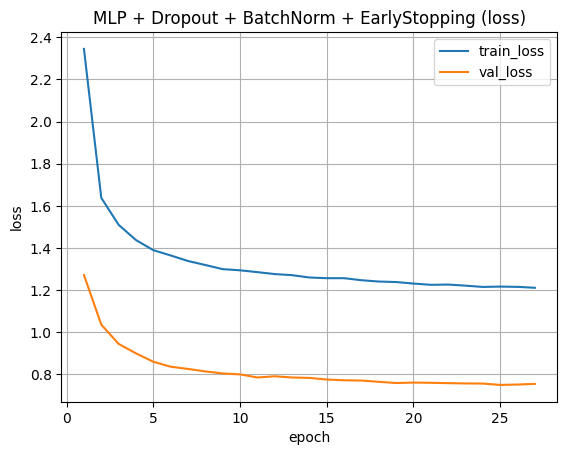

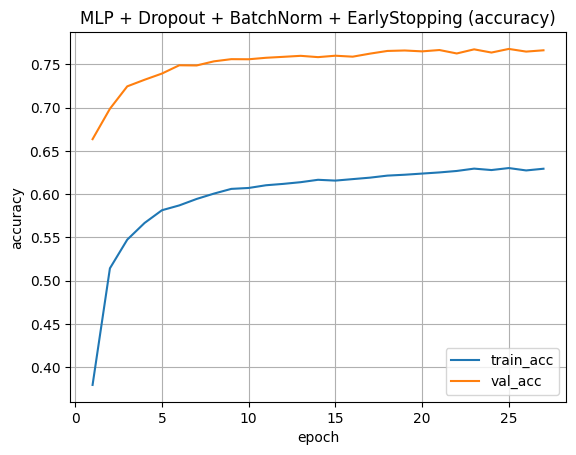

In [23]:
combo_model = MLP(hidden_dims=(64, 32), dropout_p=0.3, use_batchnorm=True).to(device)

es = EarlyStopping(patience=4, min_delta=0.0005)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss_combo, test_acc_combo = evaluate(combo_model, test_loader, criterion, device)

##### O1 :  Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.

epoch 01/8 | train loss=2.1343, acc=0.3760 | val loss=1.2709, acc=0.5991
epoch 02/8 | train loss=1.8240, acc=0.4547 | val loss=1.1837, acc=0.6343
epoch 03/8 | train loss=1.7700, acc=0.4712 | val loss=1.0919, acc=0.6637
epoch 04/8 | train loss=1.7187, acc=0.4840 | val loss=1.0512, acc=0.6722
epoch 05/8 | train loss=1.6884, acc=0.4926 | val loss=1.0094, acc=0.6875
epoch 06/8 | train loss=1.6687, acc=0.4982 | val loss=1.0684, acc=0.6610
epoch 07/8 | train loss=1.6454, acc=0.5015 | val loss=1.0865, acc=0.6688
epoch 08/8 | train loss=1.6474, acc=0.5042 | val loss=0.9926, acc=0.6910


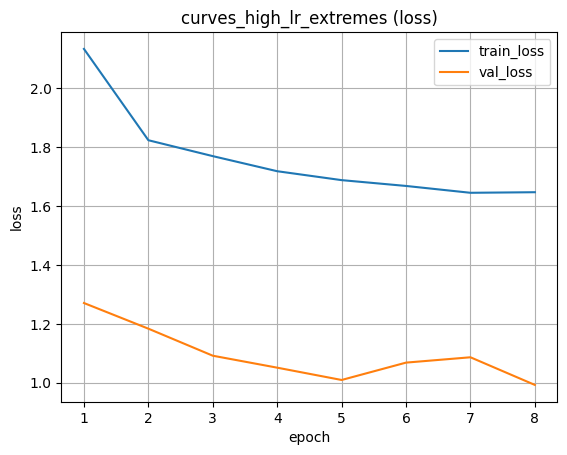

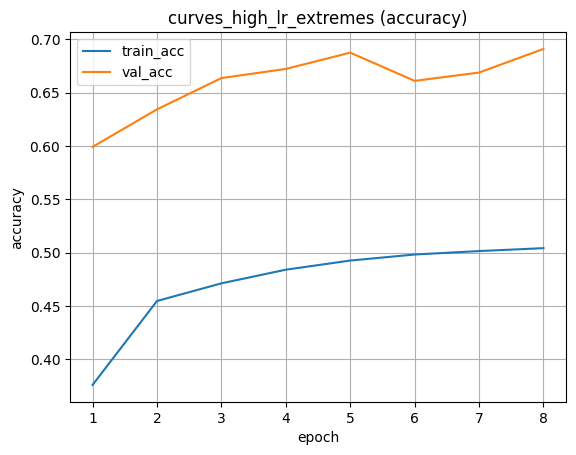

In [25]:
high_lr_model = MLP(hidden_dims = (64, 32), dropout_p = 0.3, use_batchnorm = True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(high_lr_model.parameters(), lr = 1e-1)

history_high_lr = fit(
    high_lr_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs = 8, verbose = True
)

plot_history(history_high_lr, title = "curves_high_lr_extremes")

##### O2 (LR слишком маленький): Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.

epoch 01/8 | train loss=3.8420, acc=0.0366 | val loss=3.6833, acc=0.0762
epoch 02/8 | train loss=3.6860, acc=0.0631 | val loss=3.5590, acc=0.1250
epoch 03/8 | train loss=3.5836, acc=0.0931 | val loss=3.4719, acc=0.1776
epoch 04/8 | train loss=3.5062, acc=0.1209 | val loss=3.3998, acc=0.2259
epoch 05/8 | train loss=3.4401, acc=0.1447 | val loss=3.3325, acc=0.2707
epoch 06/8 | train loss=3.3857, acc=0.1664 | val loss=3.2844, acc=0.3040
epoch 07/8 | train loss=3.3322, acc=0.1867 | val loss=3.2196, acc=0.3381
epoch 08/8 | train loss=3.2816, acc=0.2082 | val loss=3.1734, acc=0.3650


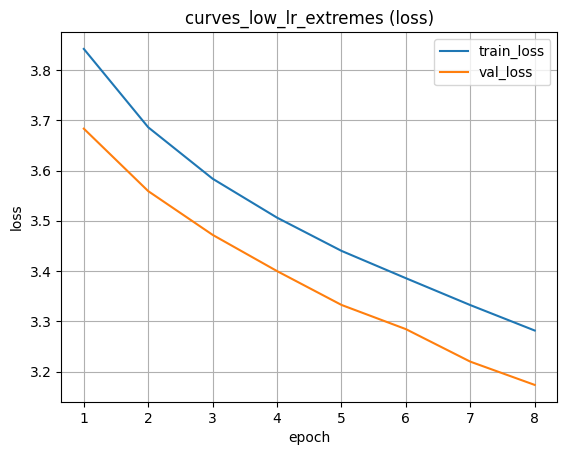

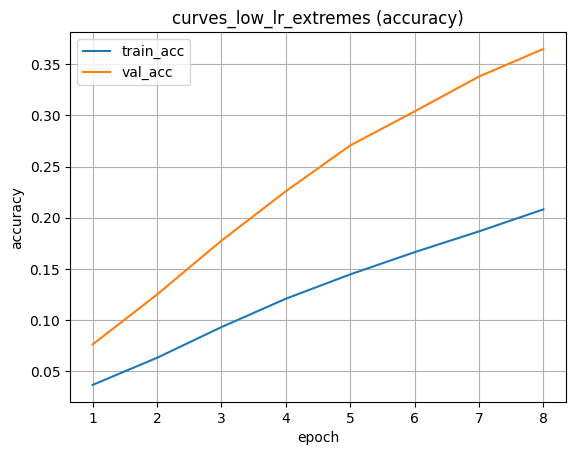

In [26]:
low_lr_model = MLP(hidden_dims=(64, 32), dropout_p = 0.3, use_batchnorm = True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(low_lr_model.parameters(), lr = 1e-5)

history_low_lr_model = fit(
    low_lr_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs = 8, verbose = True
)

plot_history(history_low_lr_model, title = "curves_low_lr_extremes")

##### O3 (SGD+momentum + weight decay): SGD с momentum (например, momentum=0.9) и weight_decay > 0 (например, 1e-4).

epoch 01/12 | train loss=3.3982, acc=0.1660 | val loss=2.9404, acc=0.3966
epoch 02/12 | train loss=2.8161, acc=0.3052 | val loss=2.3490, acc=0.5091
epoch 03/12 | train loss=2.4135, acc=0.3671 | val loss=1.9201, acc=0.5853
epoch 04/12 | train loss=2.1666, acc=0.4056 | val loss=1.6385, acc=0.6272
epoch 05/12 | train loss=2.0179, acc=0.4295 | val loss=1.4704, acc=0.6509
epoch 06/12 | train loss=1.9178, acc=0.4483 | val loss=1.3529, acc=0.6650
epoch 07/12 | train loss=1.8345, acc=0.4660 | val loss=1.2715, acc=0.6782
epoch 08/12 | train loss=1.7758, acc=0.4803 | val loss=1.2093, acc=0.6882
epoch 09/12 | train loss=1.7259, acc=0.4933 | val loss=1.1549, acc=0.7006
epoch 10/12 | train loss=1.6855, acc=0.5022 | val loss=1.1102, acc=0.7071
epoch 11/12 | train loss=1.6496, acc=0.5116 | val loss=1.0707, acc=0.7082
epoch 12/12 | train loss=1.6145, acc=0.5197 | val loss=1.0486, acc=0.7155


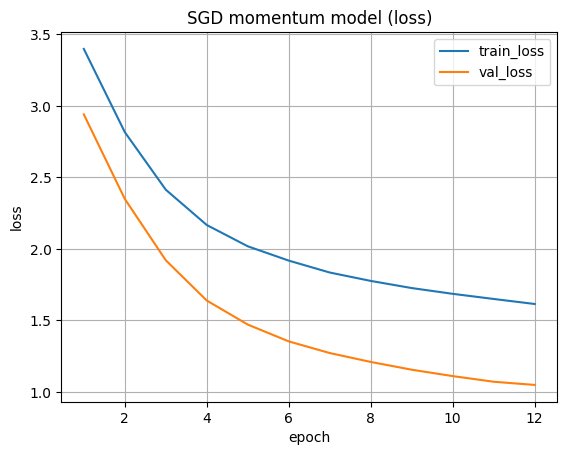

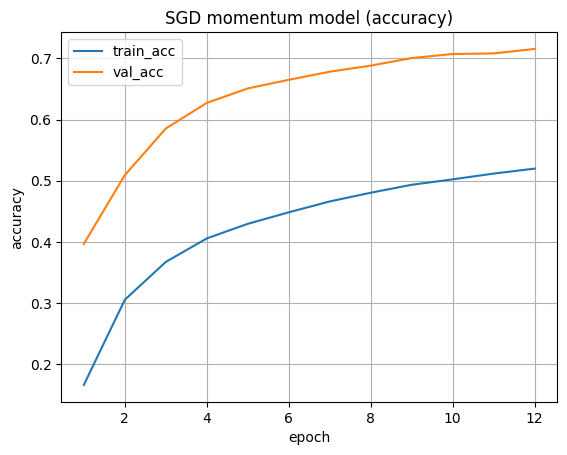

In [27]:
SGD_momentum_model = MLP(hidden_dims = (64, 32), dropout_p = 0.3, use_batchnorm = True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(SGD_momentum_model.parameters(), lr = 1e-3, momentum=0.9, weight_decay=1e-4)

history_SGD_model = fit(
    SGD_momentum_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs = 12, verbose = True
)

plot_history(history_SGD_model, title = "SGD momentum model")

Артефакты эксперементов

In [ ]:
data = [
    {
        "experiment_id": "E1_complex_baseline",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.0,
            "batchnorm": False,
            "lr": 1e-3,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 20,
        "best_val_accuracy": round(max(history_complex["val_acc"]), 4),
        "best_val_loss": round(max(history_complex["val_loss"]),4) 
    },
    {
        "experiment_id": "E2_dropout",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.3,
            "batchnorm": False,
            "lr": 1e-3,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 20,
        "best_val_accuracy": round(max(history_drop["val_acc"]), 4),
        "best_val_loss": round(max(history_drop["val_loss"]),4) 
    },
    {
        "experiment_id": "E3_batchnorm",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.0,
            "batchnorm": True,
            "lr": 1e-3,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 20,
        "best_val_accuracy": round(max(history_bn["val_acc"]), 4),
        "best_val_loss": round(max(history_bn["val_loss"]),4) 
    },
    {
        "experiment_id": "E4_early_stopping",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.3,
            "batchnorm": True,
            "lr": 1e-3,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 20, 
        "best_val_accuracy":round(max(history_combo["val_acc"]), 4),
        "best_val_loss": round(max(history_combo["val_loss"]),4) 
    },
    {
        "experiment_id": "O1_high_lr_model",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.3,
            "batchnorm": True,
            "lr": 1e-1,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 8,
        "best_val_accuracy": round(max(history_high_lr["val_acc"]), 4),
        "best_val_loss": round(max(history_high_lr["val_loss"]),4) 
    },
    {
        "experiment_id": "O2_low_lr_model",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.3,
            "batchnorm": True,
            "lr": 1e-5,
            "momentum": 0,
            "weight_decay": 0,
        },
        "epochs_trained": 8,
        "best_val_accuracy": round(max(history_low_lr_model["val_acc"]), 4),
        "best_val_loss": round(max(history_low_lr_model["val_loss"]),4) 
    },
    {
        "experiment_id": "O3_SGD_momentum",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": {
            "hidden_sizes": (64,32),
            "activation": "ReLu",
            "dropout": 0.3,
            "batchnorm": True,
            "lr": 1e-3,
            "momentum": 0.9,
            "weight_decay": 1e-4,
        },
        "epochs_trained": 12,
        "best_val_accuracy": round(max(history_SGD_model["val_acc"]), 4),
        "best_val_loss": round(max(history_SGD_model["val_loss"]),4) 
    },
]

fieldnames = [
    "experiment_id", "dataset", "seed", "model_summary",
    "dropout", "batchnorm", "epochs_trained",
    "best_val_accuracy", "best_val_loss"
]



with open("artifacts/runs.csv", mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(data)


ValueError: dict contains fields not in fieldnames: 'weight_decay', 'lr', 'momentum'

In [29]:
torch.save(model_bn.state_dict(), "artifacts/best_model.pt")

Функция для оценке на тесте

In [30]:
best_model = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)

checkpoint = torch.load("artifacts/best_model.pt", map_location=device)
best_model.load_state_dict(checkpoint) 


best_model.eval()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}")

C:\Users\s7omb\AppData\Local\Temp\ipykernel_25556\1310702677.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("artifacts/best_model.pt", map_locat

Test Accuracy: 0.8187


In [31]:
best_config = {
    "experiment_id": "E3_batchnorm",
    "dataset": "EMNIST",
    "seed": 42,
    "model": {
        "hidden_dims": [64, 32],
        "dropout_p": 0.0,
        "use_batchnorm": True
    },
    "training": {
        "learning_rate": 1e-3,
        "batch_size": 128,
        "epochs": 20
    },
    "results": {
        "best_val_accuracy": 0.8254,
        "test_accuracy": test_acc,
        "test_loss": test_loss
    }
}

with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2)

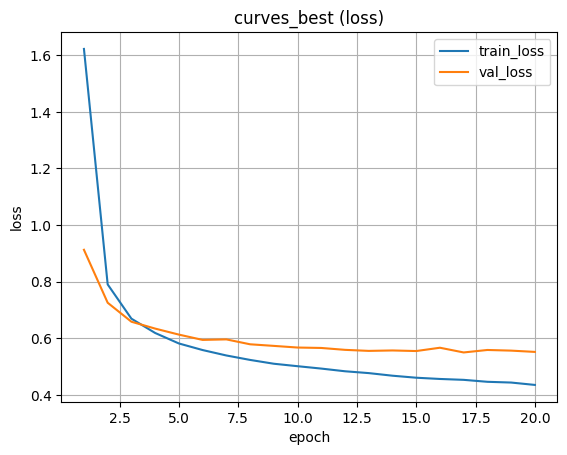

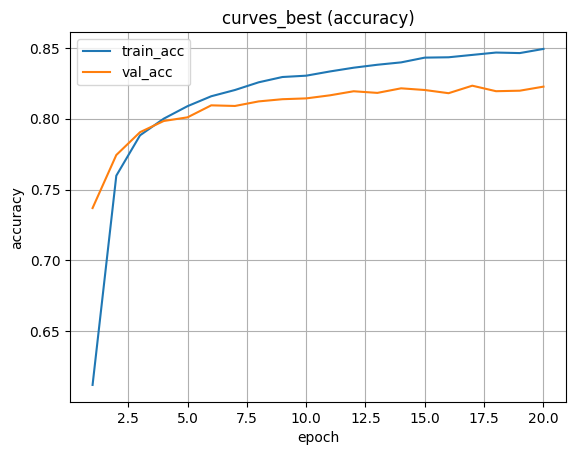

In [32]:
plot_history(history_bn, "curves_best")